# WLASL Sign Language Recognition with CNN-Mamba

This notebook implements a **MobileNetV3-Large + Selective State Space Model (Mamba)** architecture for real-time word-level American Sign Language (ASL) recognition on the WLASL dataset.

**Architecture:**
- **Spatial Encoder:** MobileNetV3-Large (ImageNet pretrained)
- **Temporal Decoder:** 2-layer selective SSM (Mamba)
- **Input:** 25 frames × 224 × 224 RGB (1 second at 25 fps)
- **Output:** 300 ASL gloss classes (WLASL300 subset)

**Key Properties:**
- Linear-time temporal complexity: O(n)
- Fixed memory state during inference (no KV cache growth)
- ~6M parameters, suitable for edge deployment

## 1. Setup and Imports

In [ ]:
# Install required packages (run once)
!pip install -q opencv-python scikit-learn seaborn

import os
import sys
import json
import time
import random
import gc
import numpy as np
import pandas as pd
import cv2
import psutil
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import mobilenet_v3_large

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

Dataset paths use a dual-source fallback system: primary videos from `wlasl-processed` with automatic fallback to `wlasl2000-resized` for missing files.

In [2]:
# Configuration
class Config:
    # Dataset
    NUM_CLASSES = 300          # WLASL300 (or 100, 1000, 2000)
    NUM_FRAMES = 16            # Frames per video (1 second at 25 fps)
    FRAME_SIZE = 224           # Spatial resolution
    
    # Model
    D_MODEL = 256              # Mamba hidden dimension
    D_STATE = 16               # SSM state dimension
    N_MAMBA_LAYERS = 2         # Number of Mamba blocks
    DROPOUT = 0.5
    
    # Training
    BATCH_SIZE = 8
    NUM_EPOCHS = 100
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4
    PATIENCE = 10              # Early stopping patience
    
    # Paths (Kaggle dual dataset fallback)
    JSON_PATH = '/kaggle/input/datasets/risangbaskoro/wlasl-processed/WLASL_v0.3.json'
    VIDEO_ROOT = '/kaggle/input/datasets/risangbaskoro/wlasl-processed/videos'
    VIDEO_ROOT_BACKUP = '/kaggle/input/datasets/sttaseen/wlasl2000-resized/wlasl-complete/videos'
    CHECKPOINT_DIR = './checkpoints'
    
    # Reproducibility
    SEED = 42

# Create checkpoint directory
os.makedirs(Config.CHECKPOINT_DIR, exist_ok=True)

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(Config.SEED)
print("Configuration loaded successfully!")

Configuration loaded successfully!


## 3. Data Exploration

Total glosses in full dataset: 2000

WLASL300 Statistics:
  Total videos: 5117
  Train: 3549 (69.4%)
  Val: 900 (17.6%)
  Test: 668 (13.1%)
  Classes: 300
  Instances per class: min=14, max=40, mean=17.1


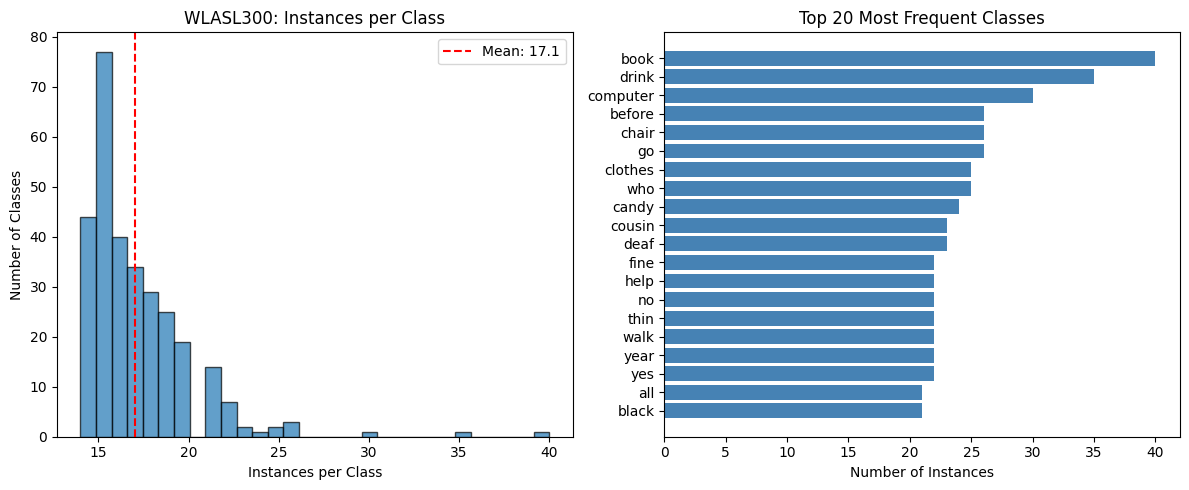


Class distribution plot saved!


In [3]:
# Load WLASL annotations
def load_wlasl_data(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    return data

data = load_wlasl_data(Config.JSON_PATH)
print(f"Total glosses in full dataset: {len(data)}")

# Get statistics for top-k classes
def analyze_subset(data, k=300):
    gloss_counts = [(entry['gloss'], len(entry['instances'])) for entry in data]
    gloss_counts.sort(key=lambda x: x[1], reverse=True)
    top_k = gloss_counts[:k]
    
    # Statistics
    subset_stats = {'train': 0, 'val': 0, 'test': 0}
    counts = []
    
    for gloss, _ in top_k:
        entry = next(e for e in data if e['gloss'] == gloss)
        class_count = {'train': 0, 'val': 0, 'test': 0, 'total': 0}
        for inst in entry['instances']:
            split = inst['split']
            subset_stats[split] += 1
            class_count[split] += 1
            class_count['total'] += 1
        counts.append(class_count['total'])
    
    total = sum(subset_stats.values())
    print(f"\nWLASL{k} Statistics:")
    print(f"  Total videos: {total}")
    print(f"  Train: {subset_stats['train']} ({subset_stats['train']/total*100:.1f}%)")
    print(f"  Val: {subset_stats['val']} ({subset_stats['val']/total*100:.1f}%)")
    print(f"  Test: {subset_stats['test']} ({subset_stats['test']/total*100:.1f}%)")
    print(f"  Classes: {k}")
    print(f"  Instances per class: min={min(counts)}, max={max(counts)}, mean={np.mean(counts):.1f}")
    
    return top_k

top_300 = analyze_subset(data, k=Config.NUM_CLASSES)

# Visualize class distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
counts = [c[1] for c in top_300]
plt.hist(counts, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Instances per Class')
plt.ylabel('Number of Classes')
plt.title('WLASL300: Instances per Class')
plt.axvline(np.mean(counts), color='red', linestyle='--', label=f'Mean: {np.mean(counts):.1f}')
plt.legend()

plt.subplot(1, 2, 2)
names = [c[0] for c in top_300[:20]]
values = [c[1] for c in top_300[:20]]
plt.barh(range(len(names)), values, color='steelblue')
plt.yticks(range(len(names)), names)
plt.xlabel('Number of Instances')
plt.title('Top 20 Most Frequent Classes')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nClass distribution plot saved!")

## 4. Data Loading

In [ ]:
# Preprocessing: Extract frames from videos to .pt files
# Run this ONCE before training to eliminate cv2/ffmpeg memory leaks
import os
import json
import gc
import cv2
import numpy as np
import torch
import psutil

FRAMES_ROOT = '/kaggle/working/frames'
MANIFEST_PATH = '/kaggle/working/frames_manifest.json'
os.makedirs(FRAMES_ROOT, exist_ok=True)

def extract_frames_from_video(video_path, num_frames=25, frame_size=224, max_retries=3):
    for attempt in range(max_retries):
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            cap.release()
            return None
        try:
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total_frames <= 0:
                return None
            
            indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
            frames = []
            failed_reads = 0
            
            for idx in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if not ret:
                    failed_reads += 1
                    if failed_reads > max(2, num_frames // 4):
                        return None
                    continue
                
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = cv2.resize(frame, (frame_size, frame_size))
                frame = frame.astype(np.float32) / 255.0
                frames.append(frame)
            
            if len(frames) == 0:
                return None
            
            while len(frames) < num_frames:
                frames.append(frames[-1])
            
            frames = np.stack(frames)
            frames = torch.from_numpy(frames).permute(3, 0, 1, 2)  # (C, T, H, W)
            return frames
        finally:
            cap.release()
            gc.collect()

def preprocess_dataset(json_path, video_root, video_root_backup, num_classes, num_frames, frame_size, splits):
    process = psutil.Process(os.getpid())
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    gloss_counts = [(entry['gloss'], len(entry['instances'])) for entry in data]
    gloss_counts.sort(key=lambda x: x[1], reverse=True)
    top_k_glosses = [g[0] for g in gloss_counts[:num_classes]]
    
    manifest = {'metadata': {'num_frames': num_frames, 'frame_size': frame_size}, 'videos': {}}
    total_videos = 0
    
    for entry in data:
        if entry['gloss'] not in top_k_glosses:
            continue
        for inst in entry['instances']:
            inst_split = inst['split']
            if inst_split not in splits:
                continue
            total_videos += 1
    
    print(f"Total videos to process: {total_videos}")
    
    processed = 0
    failed = 0
    
    for entry in data:
        if entry['gloss'] not in top_k_glosses:
            continue
        
        for inst in entry['instances']:
            inst_split = inst['split']
            if inst_split not in splits:
                continue
            
            video_id = inst['video_id']
            video_path = os.path.join(video_root, f"{video_id}.mp4")
            
            if not os.path.exists(video_path) and video_root_backup is not None:
                video_path = os.path.join(video_root_backup, f"{video_id}.mp4")
            
            if not os.path.exists(video_path):
                continue
            
            frame_path = os.path.join(FRAMES_ROOT, f"{video_id}.pt")
            
            if os.path.exists(frame_path):
                manifest['videos'][video_id] = {
                    'frame_path': frame_path,
                    'gloss': entry['gloss'],
                    'split': inst_split,
                    'label': list(top_k_glosses).index(entry['gloss']) if entry['gloss'] in top_k_glosses else -1
                }
                processed += 1
                continue
            
            frames = extract_frames_from_video(video_path, num_frames, frame_size)
            
            if frames is not None:
                torch.save(frames, frame_path)
                manifest['videos'][video_id] = {
                    'frame_path': frame_path,
                    'gloss': entry['gloss'],
                    'split': inst_split,
                    'label': list(top_k_glosses).index(entry['gloss']) if entry['gloss'] in top_k_glosses else -1
                }
                processed += 1
            else:
                failed += 1
            
            if (processed + failed) % 500 == 0:
                print(f"  Processed: {processed}, Failed: {failed}, RAM: {process.memory_info().rss / (1024**2):.1f} MB")
    
    with open(MANIFEST_PATH, 'w') as f:
        json.dump(manifest, f)
    
    print(f"\nPreprocessing complete!")
    print(f"  Successfully processed: {processed}")
    print(f"  Failed: {failed}")
    print(f"  Manifest saved to: {MANIFEST_PATH}")

import sys

# Run preprocessing with simple progress
preprocess_dataset(
    json_path=Config.JSON_PATH,
    video_root=Config.VIDEO_ROOT,
    video_root_backup=Config.VIDEO_ROOT_BACKUP,
    num_classes=Config.NUM_CLASSES,
    num_frames=Config.NUM_FRAMES,
    frame_size=Config.FRAME_SIZE,
    splits=['train', 'val', 'test']
)

gc.collect()


In [ ]:
class WLASLDatasetPreprocessed(Dataset):
    """WLASL Dataset loading from preprocessed .pt files.
    Eliminates cv2/ffmpeg from the training loop to prevent memory leaks."""
    
    def __init__(self, manifest_path, split='train', transform=None):
        self.split = split
        self.transform = transform
        
        with open(manifest_path, 'r') as f:
            self.manifest = json.load(f)
        
        self.num_frames = self.manifest['metadata']['num_frames']
        self.frame_size = self.manifest['metadata']['frame_size']
        
        self.samples = []
        for video_id, info in self.manifest['videos'].items():
            if info['split'] == split or (split == 'train' and info['split'] in ['train', 'val']):
                self.samples.append({
                    'video_id': video_id,
                    'frame_path': info['frame_path'],
                    'label': info['label'],
                    'gloss': info['gloss']
                })
        
        print(f"WLASL {split}: {len(self.samples)} samples loaded")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        frames = torch.load(sample['frame_path'], map_location='cpu')
        
        if self.transform:
            frames = self.transform(frames)
        
        return frames, sample['label'], sample['video_id']


class RandomHorizontalFlipVideo:
    def __init__(self, p=0.5):
        self.p = p
    
    def __call__(self, frames):
        if random.random() < self.p:
            frames = torch.flip(frames, dims=[3])
        return frames


class NormalizeVideo:
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean).view(3, 1, 1, 1)
        self.std = torch.tensor(std).view(3, 1, 1, 1)
    
    def __call__(self, frames):
        return (frames - self.mean) / self.std


def get_data_loaders(manifest_path, num_classes=300, batch_size=32, num_workers=4,
                     pin_memory_train=True, pin_memory_eval=False,
                     include_train_val=True, include_test=True):
    train_transform = transforms.Compose([
        RandomHorizontalFlipVideo(p=0.5),
        NormalizeVideo(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        NormalizeVideo(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    loaders = {}
    
    if include_train_val:
        train_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='train',
            transform=train_transform
        )
        val_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='val',
            transform=val_transform
        )
        
        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            num_workers=num_workers, pin_memory=pin_memory_train, drop_last=True
        )
        val_loader = DataLoader(
            val_dataset, batch_size=batch_size, shuffle=False,
            num_workers=num_workers, pin_memory=pin_memory_eval
        )
        loaders['train'] = train_loader
        loaders['val'] = val_loader
    
    if include_test:
        test_dataset = WLASLDatasetPreprocessed(
            manifest_path=manifest_path,
            split='test',
            transform=val_transform
        )
        test_loader = DataLoader(
            test_dataset, batch_size=batch_size, shuffle=False,
            num_workers=num_workers, pin_memory=pin_memory_eval
        )
        loaders['test'] = test_loader
    
    print("\nData loaders created (preprocessed):")
    if 'train' in loaders:
        print(f"  Train batches: {len(loaders['train'])}")
    if 'val' in loaders:
        print(f"  Val batches: {len(loaders['val'])}")
    if 'test' in loaders:
        print(f"  Test batches: {len(loaders['test'])}")
    
    return loaders


# Create data loaders from preprocessed frames
MANIFEST_PATH = '/kaggle/working/frames_manifest.json'

loaders = get_data_loaders(
    manifest_path=MANIFEST_PATH,
    num_classes=Config.NUM_CLASSES,
    batch_size=Config.BATCH_SIZE,
    num_workers=4,
    pin_memory_train=True,
    pin_memory_eval=False,
    include_test=False
)

train_loader = loaders['train']
val_loader = loaders['val']


## 5. Model Definition

In [5]:
class SelectiveSSM(nn.Module):
    """Simplified Selective State Space Model (Mamba) in pure PyTorch."""
    
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(self.expand * self.d_model)
        
        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        
        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner, out_channels=self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True
        )
        
        self.x_proj = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)
        
        A = torch.arange(1, d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
    
    def forward(self, x):
        B, L, D = x.shape
        
        x_and_res = self.in_proj(x)
        x_ssm, res = x_and_res.split([self.d_inner, self.d_inner], dim=-1)
        
        x_conv = self.conv1d(x_ssm.transpose(1, 2))[:, :, :L]
        x_conv = x_conv.transpose(1, 2)
        x_conv = F.silu(x_conv)
        
        y = self.ssm(x_conv)
        y = y * F.silu(res)
        
        return self.out_proj(y)
    
    def ssm(self, x):
        B, L, _ = x.shape
        
        x_dbl = self.x_proj(x)
        delta, B_ssm, C = x_dbl.split([1, self.d_state, self.d_state], dim=-1)
        
        delta = F.softplus(self.dt_proj(delta))
        A = -torch.exp(self.A_log.float())
        
        return self.selective_scan(x, delta, A, B_ssm, C)
    
    def selective_scan(self, x, delta, A, B, C):
        batch_size, L, d_in = x.shape
        d_state = A.size(1)
        
        h = torch.zeros(batch_size, d_in, d_state, device=x.device, dtype=x.dtype)
        ys = []

        for t in range(L):
            delta_t = delta[:, t, :]
            A_bar = torch.exp(delta_t.unsqueeze(-1) * A.unsqueeze(0))
            B_bar = delta_t.unsqueeze(-1) * B[:, t, :].unsqueeze(1)

            h = A_bar * h + B_bar * x[:, t, :].unsqueeze(-1)
            y_t = torch.sum(C[:, t, :].unsqueeze(1) * h, dim=-1)
            ys.append(y_t)
        
        y = torch.stack(ys, dim=1)
        y = y + x * self.D.unsqueeze(0).unsqueeze(0)
        
        return y


class MambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.mixer = SelectiveSSM(d_model, d_state, d_conv, expand)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = self.mixer(x)
        x = self.dropout(x)
        return x + residual


class MobileNetV3_Mamba(nn.Module):
    """CNN-Mamba hybrid for sign language recognition."""
    
    def __init__(self, num_classes=300, d_model=256, n_mamba_layers=2,
                 d_state=16, dropout=0.5, pretrained=True):
        super().__init__()
        
        # Spatial encoder
        mobilenet = mobilenet_v3_large(pretrained=pretrained)
        self.spatial_encoder = nn.Sequential(*list(mobilenet.features.children()))
        self.spatial_pool = nn.AdaptiveAvgPool2d(1)
        self.spatial_dim = 960
        
        # Projection
        self.input_proj = nn.Linear(self.spatial_dim, d_model)
        
        # Temporal decoder
        self.temporal_decoder = nn.ModuleList([
            MambaBlock(d_model, d_state=d_state, dropout=dropout)
            for _ in range(n_mamba_layers)
        ])
        
        # Classification head
        self.temporal_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def extract_frame_features(self, frames):
        B, C, T, H, W = frames.shape
        frames_flat = frames.permute(0, 2, 1, 3, 4).contiguous().view(B * T, C, H, W)
        
        features = self.spatial_encoder(frames_flat)
        features = self.spatial_pool(features)
        features = features.view(B, T, self.spatial_dim)
        
        return features
    
    def forward(self, frames):
        x = self.extract_frame_features(frames)
        x = self.input_proj(x)
        
        for block in self.temporal_decoder:
            x = block(x)
        
        x = x.transpose(1, 2)
        x = self.temporal_pool(x).squeeze(-1)
        
        return self.classifier(x)

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = MobileNetV3_Mamba(
    num_classes=Config.NUM_CLASSES,
    d_model=Config.D_MODEL,
    n_mamba_layers=Config.N_MAMBA_LAYERS,
    d_state=Config.D_STATE,
    dropout=Config.DROPOUT,
    pretrained=True,
)

# Use DataParallel if multiple GPUs available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(device)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel Summary:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size (FP32): {total_params * 4 / (1024**2):.2f} MB")

# Test forward pass
dummy_input = torch.randn(2, 3, Config.NUM_FRAMES, Config.FRAME_SIZE, Config.FRAME_SIZE).to(device)
output = model(dummy_input)
print(f"\nTest forward pass:")
print(f"  Input shape: {dummy_input.shape}")
print(f"  Output shape: {output.shape}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 21.1M/21.1M [00:00<00:00, 122MB/s] 


Using 2 GPUs!

Model Summary:
  Total parameters: 4,141,404
  Trainable parameters: 4,141,404
  Model size (FP32): 15.80 MB

Test forward pass:
  Input shape: torch.Size([2, 3, 16, 224, 224])
  Output shape: torch.Size([2, 300])


## 6. Training

In [ ]:
# Setup training
criterion = nn.CrossEntropyLoss()

# Separate learning rates for pretrained and new layers
pretrained_params = []
new_params = []
for name, param in model.named_parameters():
    if 'spatial_encoder' in name:
        pretrained_params.append(param)
    else:
        new_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': pretrained_params, 'lr': Config.LEARNING_RATE * 0.1},
    {'params': new_params, 'lr': Config.LEARNING_RATE}
], weight_decay=Config.WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.3
)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_top5': [],
    'val_top10': []
}

best_val_loss = float('inf')
patience_counter = 0

output_dir = '/kaggle/working/checkpoints'
os.makedirs(output_dir, exist_ok=True)

process = psutil.Process(os.getpid())

def get_ram_mb():
    return process.memory_info().rss / (1024 ** 2)


def accuracy(output, target, topk=(1,)):
    maxk = max(topk)
    batch_size = target.size(0)
    _, pred = output.topk(maxk, 1, True, True)
    pred = pred.t()
    correct = pred.eq(target.view(1, -1).expand_as(pred))
    res = []
    for k in topk:
        correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
        res.append(correct_k.mul_(100.0 / batch_size))
    return res

# Training loop
for epoch in range(1, Config.NUM_EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{Config.NUM_EPOCHS}")
    print(f"{'='*60}")
    print(f"RAM at epoch start: {get_ram_mb():.1f} MB")
    
    # Training
    model.train()
    train_loss = 0.0
    train_top1 = 0.0
    train_top5 = 0.0
    
    for batch_idx, (frames, labels, _) in enumerate(train_loader):
        frames = frames.to(device)
        labels = labels.to(device)
        
        outputs = model(frames)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        acc1, acc5 = accuracy(outputs, labels, topk=(1, 5))
        train_loss += loss.item()
        train_top1 += acc1.item()
        train_top5 += acc5.item()
        
        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(train_loader)} "
                  f"Loss: {loss.item():.4f} "
                  f"Top-1: {acc1.item():.2f}% "
                  f"RAM: {get_ram_mb():.1f} MB")
            gc.collect()
        
        del frames, labels, outputs, loss, acc1, acc5
    
    train_loss /= len(train_loader)
    train_top1 /= len(train_loader)
    train_top5 /= len(train_loader)
    
    print(f"RAM after train: {get_ram_mb():.1f} MB")
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_top1 = 0.0
    val_top5 = 0.0
    val_top10 = 0.0
    
    with torch.no_grad():
        for batch_idx, (frames, labels, _) in enumerate(val_loader):
            frames = frames.to(device)
            labels = labels.to(device)
            
            outputs = model(frames)
            loss = criterion(outputs, labels)
            
            acc1, acc5, acc10 = accuracy(outputs, labels, topk=(1, 5, 10))
            val_loss += loss.item()
            val_top1 += acc1.item()
            val_top5 += acc5.item()
            val_top10 += acc10.item()
            
            if batch_idx % 10 == 0:
                print(f"  Val batch {batch_idx}/{len(val_loader)} "
                      f"RAM: {get_ram_mb():.1f} MB")
                gc.collect()
            
            del frames, labels, outputs, loss, acc1, acc5, acc10
    
    val_loss /= len(val_loader)
    val_top1 /= len(val_loader)
    val_top5 /= len(val_loader)
    val_top10 /= len(val_loader)
    
    print(f"RAM after val: {get_ram_mb():.1f} MB")
    
    # Update history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_top1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_top1)
    history['val_top5'].append(val_top5)
    history['val_top10'].append(val_top10)
    
    print(f"\nEpoch {epoch} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Top-1: {train_top1:.2f}% | Top-5: {train_top5:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Top-1: {val_top1:.2f}% | Top-5: {val_top5:.2f}% | Top-10: {val_top10:.2f}%")
    
    # Save best model by validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'history': history
        }, os.path.join(output_dir, 'best_model.pth'))
        print(f"  ✓ New best model saved (Val Loss: {val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= Config.PATIENCE:
        print(f"\nEarly stopping triggered after {epoch} epochs")
        break
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Cleanup to avoid CPU RAM growth
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"RAM after gc: {get_ram_mb():.1f} MB")

print(f"\nTraining completed! Best validation loss: {best_val_loss:.4f}")


Epoch 1/100
  Batch 0/556 Loss: 6.8846 Top-1: 0.00%
  Batch 10/556 Loss: 6.9447 Top-1: 0.00%
  Batch 20/556 Loss: 6.2246 Top-1: 0.00%
  Batch 30/556 Loss: 7.1122 Top-1: 0.00%
  Batch 40/556 Loss: 6.5254 Top-1: 0.00%
  Batch 50/556 Loss: 6.1535 Top-1: 0.00%
  Batch 60/556 Loss: 6.0974 Top-1: 0.00%
  Batch 70/556 Loss: 6.7763 Top-1: 0.00%
  Batch 80/556 Loss: 6.9978 Top-1: 0.00%
  Batch 90/556 Loss: 6.6390 Top-1: 0.00%
  Batch 100/556 Loss: 7.1772 Top-1: 0.00%
  Batch 110/556 Loss: 6.3968 Top-1: 0.00%
  Batch 120/556 Loss: 6.2895 Top-1: 0.00%
  Batch 130/556 Loss: 5.9803 Top-1: 0.00%
  Batch 140/556 Loss: 6.7333 Top-1: 0.00%
  Batch 150/556 Loss: 7.2624 Top-1: 0.00%
  Batch 160/556 Loss: 6.9433 Top-1: 0.00%
  Batch 170/556 Loss: 6.2211 Top-1: 0.00%
  Batch 180/556 Loss: 7.2373 Top-1: 0.00%
  Batch 190/556 Loss: 6.3246 Top-1: 0.00%
  Batch 200/556 Loss: 6.7721 Top-1: 0.00%
  Batch 210/556 Loss: 5.7312 Top-1: 0.00%
  Batch 220/556 Loss: 6.9512 Top-1: 0.00%


[mov,mp4,m4a,3gp,3g2,mj2 @ 0xd771a00] stream 1, offset 0x3b468: partial file
[h264 @ 0xd7b4880] Invalid NAL unit size (745 > 472).
[h264 @ 0xd7b4880] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xd771a00] stream 1, offset 0x3b7d3: partial file
[h264 @ 0xd7b4880] Invalid NAL unit size (745 > 472).
[h264 @ 0xd7b4880] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xd771a00] stream 1, offset 0x3b468: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xd771a00] stream 1, offset 0x3b7d3: partial file


  Batch 230/556 Loss: 7.0906 Top-1: 0.00%
  Batch 240/556 Loss: 6.3612 Top-1: 0.00%
  Batch 250/556 Loss: 6.2574 Top-1: 0.00%
  Batch 260/556 Loss: 6.6300 Top-1: 0.00%
  Batch 270/556 Loss: 6.5366 Top-1: 0.00%


[h264 @ 0x11906880] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x11906880] missing picture in access unit with size 10780
[h264 @ 0x11954b00] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x11954b00] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x12318700] stream 1, offset 0x2a27a7: partial file
[h264 @ 0x11906880] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x11906880] missing picture in access unit with size 10780
[h264 @ 0x1199e580] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x1199e580] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x12318700] stream 1, offset 0x2a27a7: partial file
[h264 @ 0x11906880] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x11906880] missing picture in access unit with size 10780
[h264 @ 0x1199e580] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x1199e580] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x12318700] stream 1, offset 0x2a27a7: partial file
[h264 @ 0x11906880] In

  Batch 280/556 Loss: 5.9675 Top-1: 0.00%
  Batch 290/556 Loss: 6.0961 Top-1: 0.00%
  Batch 300/556 Loss: 6.2880 Top-1: 0.00%
  Batch 310/556 Loss: 6.6095 Top-1: 0.00%
  Batch 320/556 Loss: 6.2426 Top-1: 0.00%
  Batch 330/556 Loss: 5.9490 Top-1: 0.00%
  Batch 340/556 Loss: 5.7881 Top-1: 12.50%
  Batch 350/556 Loss: 6.9366 Top-1: 0.00%
  Batch 360/556 Loss: 5.8147 Top-1: 0.00%
  Batch 370/556 Loss: 6.2567 Top-1: 0.00%
  Batch 380/556 Loss: 6.1205 Top-1: 0.00%
  Batch 390/556 Loss: 5.4764 Top-1: 0.00%
  Batch 400/556 Loss: 6.4095 Top-1: 0.00%
  Batch 410/556 Loss: 6.3335 Top-1: 0.00%
  Batch 420/556 Loss: 5.9668 Top-1: 0.00%
  Batch 430/556 Loss: 6.1703 Top-1: 0.00%
  Batch 440/556 Loss: 6.8009 Top-1: 0.00%
  Batch 450/556 Loss: 6.1278 Top-1: 0.00%
  Batch 460/556 Loss: 6.2754 Top-1: 0.00%
  Batch 470/556 Loss: 6.2474 Top-1: 0.00%
  Batch 480/556 Loss: 6.3311 Top-1: 0.00%
  Batch 490/556 Loss: 6.1853 Top-1: 0.00%
  Batch 500/556 Loss: 5.8648 Top-1: 0.00%
  Batch 510/556 Loss: 6.1480 Top-

...

  Batch 270/556 Loss: 0.7057 Top-1: 87.50%
  Batch 280/556 Loss: 1.2101 Top-1: 50.00%
  Batch 290/556 Loss: 1.2663 Top-1: 75.00%
  Batch 300/556 Loss: 0.9872 Top-1: 75.00%
  Batch 310/556 Loss: 0.8357 Top-1: 75.00%
  Batch 320/556 Loss: 1.3203 Top-1: 62.50%
  Batch 330/556 Loss: 0.8558 Top-1: 87.50%
  Batch 340/556 Loss: 2.1182 Top-1: 62.50%
  Batch 350/556 Loss: 0.8017 Top-1: 75.00%
  Batch 360/556 Loss: 1.3356 Top-1: 62.50%
  Batch 370/556 Loss: 1.1554 Top-1: 50.00%
  Batch 380/556 Loss: 0.8543 Top-1: 62.50%
  Batch 390/556 Loss: 0.5751 Top-1: 75.00%
  Batch 400/556 Loss: 1.1079 Top-1: 50.00%
  Batch 410/556 Loss: 1.3728 Top-1: 50.00%
  Batch 420/556 Loss: 1.3053 Top-1: 62.50%
  Batch 430/556 Loss: 1.7083 Top-1: 25.00%
  Batch 440/556 Loss: 1.0422 Top-1: 62.50%
  Batch 450/556 Loss: 0.8170 Top-1: 75.00%
  Batch 460/556 Loss: 1.0114 Top-1: 62.50%
  Batch 470/556 Loss: 1.5177 Top-1: 50.00%
  Batch 480/556 Loss: 1.5552 Top-1: 50.00%
  Batch 490/556 Loss: 1.0560 Top-1: 75.00%
  Batch 500

[h264 @ 0x22c8b3c0] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x22c8b3c0] missing picture in access unit with size 10780
[h264 @ 0x22c40b40] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x22c40b40] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xd7a46c0] stream 1, offset 0x2a27a7: partial file
[h264 @ 0x22c8b3c0] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x22c8b3c0] missing picture in access unit with size 10780
[h264 @ 0x119877c0] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x119877c0] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xd7a46c0] stream 1, offset 0x2a27a7: partial file
[h264 @ 0x22c8b3c0] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x22c8b3c0] missing picture in access unit with size 10780
[h264 @ 0x119877c0] Invalid NAL unit size (71678 > 10776).
[h264 @ 0x119877c0] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0xd7a46c0] stream 1, offset 0x2a27a7: partial file
[h264 @ 0x22c8b3c0] Inval

  Batch 220/556 Loss: 0.4590 Top-1: 87.50%
  Batch 230/556 Loss: 1.6739 Top-1: 37.50%
  Batch 240/556 Loss: 0.4833 Top-1: 87.50%
  Batch 250/556 Loss: 1.0160 Top-1: 62.50%
  Batch 260/556 Loss: 1.5351 Top-1: 37.50%
  Batch 270/556 Loss: 1.8047 Top-1: 37.50%
  Batch 280/556 Loss: 0.4685 Top-1: 87.50%
  Batch 290/556 Loss: 1.1651 Top-1: 50.00%
  Batch 300/556 Loss: 0.8254 Top-1: 75.00%
  Batch 310/556 Loss: 1.4289 Top-1: 50.00%
  Batch 320/556 Loss: 0.5986 Top-1: 87.50%
  Batch 330/556 Loss: 1.3225 Top-1: 75.00%
  Batch 340/556 Loss: 1.1255 Top-1: 75.00%
  Batch 350/556 Loss: 0.4927 Top-1: 75.00%
  Batch 360/556 Loss: 0.8520 Top-1: 75.00%
  Batch 370/556 Loss: 0.8839 Top-1: 75.00%
  Batch 380/556 Loss: 0.8847 Top-1: 62.50%
  Batch 390/556 Loss: 0.8644 Top-1: 62.50%
  Batch 400/556 Loss: 0.5490 Top-1: 62.50%
  Batch 410/556 Loss: 0.9172 Top-1: 37.50%
  Batch 420/556 Loss: 0.7926 Top-1: 62.50%
  Batch 430/556 Loss: 1.4254 Top-1: 50.00%
  Batch 440/556 Loss: 0.7213 Top-1: 75.00%
  Batch 450

[mov,mp4,m4a,3gp,3g2,mj2 @ 0x22c77300] stream 1, offset 0x3b468: partial file
[h264 @ 0xd905180] Invalid NAL unit size (745 > 472).
[h264 @ 0xd905180] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x22c77300] stream 1, offset 0x3b7d3: partial file
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x22c77300] stream 1, offset 0x3b468: partial file
[h264 @ 0xd905180] Invalid NAL unit size (745 > 472).
[h264 @ 0xd905180] Error splitting the input into NAL units.
[mov,mp4,m4a,3gp,3g2,mj2 @ 0x22c77300] stream 1, offset 0x3b7d3: partial file


  Batch 20/556 Loss: 0.7487 Top-1: 87.50%
  Batch 30/556 Loss: 0.5557 Top-1: 75.00%
  Batch 40/556 Loss: 0.5184 Top-1: 87.50%
  Batch 50/556 Loss: 1.4000 Top-1: 50.00%
  Batch 60/556 Loss: 0.6907 Top-1: 75.00%
  Batch 70/556 Loss: 0.6331 Top-1: 87.50%
  Batch 80/556 Loss: 1.1001 Top-1: 75.00%
  Batch 90/556 Loss: 1.1099 Top-1: 62.50%
  Batch 100/556 Loss: 0.3460 Top-1: 87.50%
  Batch 110/556 Loss: 1.9379 Top-1: 25.00%
  Batch 120/556 Loss: 1.0467 Top-1: 75.00%
  Batch 130/556 Loss: 0.2224 Top-1: 100.00%
  Batch 140/556 Loss: 1.5509 Top-1: 62.50%
  Batch 150/556 Loss: 0.8951 Top-1: 87.50%
  Batch 160/556 Loss: 0.4033 Top-1: 62.50%
  Batch 170/556 Loss: 0.8912 Top-1: 75.00%
  Batch 180/556 Loss: 0.5952 Top-1: 87.50%


## 7. Training Visualization

In [1]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss over Epochs')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['train_acc'], label='Train Top-1')
axes[0, 1].plot(history['val_acc'], label='Val Top-1')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Top-1 Accuracy over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(history['val_top5'], label='Val Top-5', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_title('Validation Top-5 Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(history['val_top10'], label='Val Top-10', color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].set_title('Validation Top-10 Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history plot saved!")

NameError: name 'plt' is not defined

## 8. Test Set Evaluation

In [ ]:
# Create test loader only when needed (using preprocessed frames)
loaders = get_data_loaders(
    manifest_path=MANIFEST_PATH,
    num_classes=Config.NUM_CLASSES,
    batch_size=Config.BATCH_SIZE,
    num_workers=4,
    pin_memory_train=False,
    pin_memory_eval=False,
    include_train_val=False,
    include_test=True
)

test_loader = loaders['test']

# Load best model
checkpoint = torch.load(f'{Config.CHECKPOINT_DIR}/best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(Val Top-1: {checkpoint['val_acc']:.2f}%)")

# Evaluate on test set
test_top1 = 0.0
test_top5 = 0.0
test_top10 = 0.0

all_preds = []
all_labels = []
inference_times = []

with torch.no_grad():
    for frames, labels, _ in test_loader:
        frames = frames.to(device)
        labels = labels.to(device)
        
        # Measure inference time
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()
        
        outputs = model(frames)
        
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end = time.time()
        
        batch_time = (end - start) / frames.size(0)
        inference_times.append(batch_time)
        
        # Metrics
        acc1, acc5, acc10 = accuracy(outputs, labels, topk=(1, 5, 10))
        test_top1 += acc1.item()
        test_top5 += acc5.item()
        test_top10 += acc10.item()
        
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [ ]:
# CPU Speed Test for Edge Deployment
print("\n" + "=" * 60)
print("CPU INFERENCE SPEED TEST (Edge Deployment Simulation)")
print("=" * 60)

class Trainer:
    def __init__(self, model):
        self.model = model
    
    def evaluate_cpu_speed(self, dataloader, num_runs=100):
        self.model.eval()
        self.model = self.model.cpu()
        
        # Get a sample input
        sample_input = None
        for frames, _, _ in dataloader:
            sample_input = frames[:1].cpu()
            break
        
        if sample_input is None:
            return {'avg_ms': 0.0, 'std_ms': 0.0}
        
        # Warmup
        with torch.no_grad():
            for _ in range(10):
                _ = self.model(sample_input)
        
        # Benchmark
        times = []
        for _ in range(num_runs):
            start = time.time()
            with torch.no_grad():
                _ = self.model(sample_input)
            end = time.time()
            times.append((end - start) * 1000)
        
        return {
            'avg_ms': np.mean(times),
            'std_ms': np.std(times)
        }

trainer = Trainer(model)
results_cpu = trainer.evaluate_cpu_speed(loaders['test'], num_runs=100)

print(f"\nCPU Inference: {results_cpu['avg_ms']:.2f} ± {results_cpu['std_ms']:.2f} ms")
print(f"CPU Throughput: {1000/results_cpu['avg_ms']:.1f} videos/sec")

# Also update saved results with CPU metrics
results['cpu_inference_ms'] = results_cpu['avg_ms']
results['cpu_throughput'] = 1000 / results_cpu['avg_ms']
with open('test_results.json', 'w') as f:
    json.dump({k: float(v) if isinstance(v, (np.floating, np.integer)) else v 
               for k, v in results.items()}, f, indent=2)
print("Updated results with CPU metrics")

## 9. Confusion Matrix and Analysis

In [ ]:
# Plot confusion matrix for top 20 classes
from sklearn.metrics import confusion_matrix

class_counts = Counter(all_labels)
top_20_classes = [c for c, _ in class_counts.most_common(20)]

mask = np.isin(all_labels, top_20_classes)
y_true_subset = np.array(all_labels)[mask]
y_pred_subset = np.array(all_preds)[mask]

cm = confusion_matrix(y_true_subset, y_pred_subset, labels=top_20_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 12))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=top_20_classes, yticklabels=top_20_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Normalized Confusion Matrix (Top 20 Classes)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

# Identify most confused class pairs
confusions = []
for i in range(len(top_20_classes)):
    for j in range(len(top_20_classes)):
        if i != j and cm[i, j] > 0:
            confusions.append((top_20_classes[i], top_20_classes[j], cm[i, j]))

confusions.sort(key=lambda x: x[2], reverse=True)
print("\nTop 10 most confused pairs:")
for true_class, pred_class, count in confusions[:10]:
    print(f"  True: {true_class}, Pred: {pred_class}, Count: {count}")

## 10. Failure Case Analysis

In [ ]:
# Analyze failure cases
failures = [(i, true, pred) for i, (true, pred) in enumerate(zip(all_labels, all_preds)) if true != pred]
print(f"Total failures: {len(failures)} out of {len(all_labels)} ({len(failures)/len(all_labels)*100:.1f}%)")

# Most commonly misclassified classes
misclassified_counts = Counter([true for _, true, _ in failures])
print("\nMost commonly misclassified classes:")
for class_idx, count in misclassified_counts.most_common(10):
    class_name = top_300[class_idx][0] if class_idx < len(top_300) else f"Class_{class_idx}"
    total = class_counts[class_idx]
    print(f"  {class_name}: {count}/{total} misclassified ({count/total*100:.1f}%)")

# Most common wrong predictions
wrong_pred_counts = Counter([pred for _, _, pred in failures])
print("\nMost common wrong predictions:")
for class_idx, count in wrong_pred_counts.most_common(10):
    class_name = top_300[class_idx][0] if class_idx < len(top_300) else f"Class_{class_idx}"
    print(f"  {class_name}: predicted {count} times incorrectly")

## 11. Export Model for Edge Deployment

In [ ]:
# Export to TorchScript for deployment
model.eval()

# Trace the model
# Note: For CPU export, ensure model is on CPU before tracing
model = model.to(device)
example_input = torch.randn(1, 3, Config.NUM_FRAMES, Config.FRAME_SIZE, Config.FRAME_SIZE).to(device)

try:
    traced_model = torch.jit.trace(model, example_input)
    traced_model.save('mobilenetv3_mamba_wlasl300.pt')
    print("Model exported to TorchScript: mobilenetv3_mamba_wlasl300.pt")
    
    # Verify
    loaded_model = torch.jit.load('mobilenetv3_mamba_wlasl300.pt')
    with torch.no_grad():
        output = loaded_model(example_input)
    print(f"Verification successful! Output shape: {output.shape}")
except Exception as e:
    print(f"TorchScript export failed: {e}")
    print("Saving state dict instead...")
    torch.save(model.state_dict(), 'mobilenetv3_mamba_wlasl300_state_dict.pth')
    print("State dict saved: mobilenetv3_mamba_wlasl300_state_dict.pth")

# Print final summary
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"Model: MobileNetV3-Large + {Config.N_MAMBA_LAYERS}-layer Mamba")
print(f"Dataset: WLASL{Config.NUM_CLASSES} (dual-source fallback loading)")
print(f"Input: {Config.NUM_FRAMES} frames × {Config.FRAME_SIZE}×{Config.FRAME_SIZE} RGB")
print(f"Parameters: {total_params:,}")
print(f"Model Size: {total_params * 4 / (1024**2):.2f} MB")
print(f"Test Top-1: {test_top1:.2f}%")
print(f"Test Top-5: {test_top5:.2f}%")
print(f"Test Top-10: {test_top10:.2f}%")
print(f"GPU Inference: {avg_inference_time:.2f} ms/video")
print(f"CPU Inference: {results_cpu['avg_ms']:.2f} ± {results_cpu['std_ms']:.2f} ms/video")
print("=" * 60)